In [1]:
import networkx as nx
import community as community_louvain
from networkx.algorithms import community
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#Importar datos
filename = 'celegans_connectome.csv'
df_elegans = pd.read_csv(filename)
df_elegans.head()

,Unnamed: 0,Neuron,Target,weight,Neurotransmitter
0,0,ADAL,AIBL,1.0,exc
1,1,ADAL,AIBR,2.0,exc
2,2,ADAL,AVAR,2.0,exc
3,3,ADAL,AVBL,4.0,exc
4,4,ADAL,AVBR,7.0,exc


In [3]:
G_elegans = nx.from_pandas_edgelist(df_elegans, source='Neuron', target='Target', edge_attr=['weight','Neurotransmitter'], create_using=nx.DiGraph())

#Generar grafo: componente fuertemente conexa más grande, sin autoenlaces
G = G_elegans.copy()
G.remove_edges_from(nx.selfloop_edges(G))
largest_scc = max(nx.strongly_connected_components(G), key=len)
G = G.subgraph(largest_scc).copy()

In [ ]:
#Algoritmo de Louvain 

G_undirected = G.to_undirected()
partition_louvain = community_louvain.best_partition(G_undirected)
modularity_louvain = community_louvain.modularity(partition_louvain, G_undirected)

print(f"Modularidad Louvain: {modularity_louvain:.4f}")


Modularidad Louvain: 0.4944


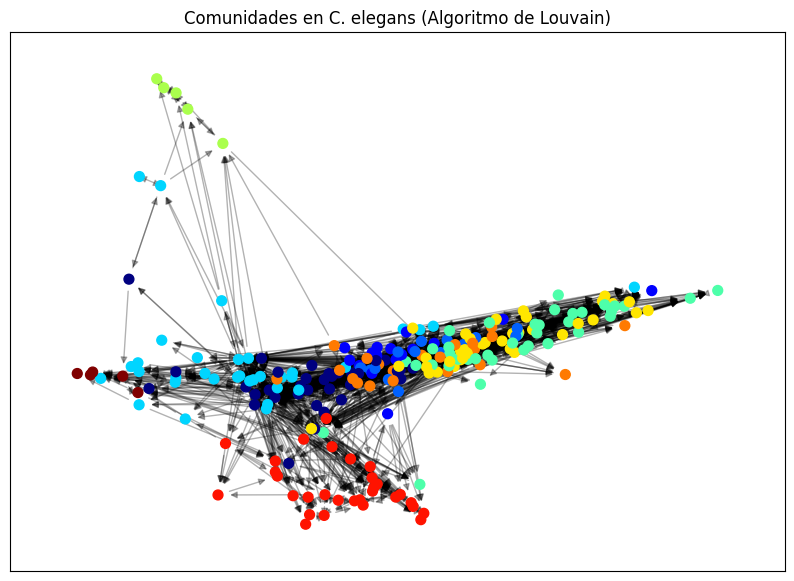

In [5]:
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=50, 
                       node_color=list(partition_louvain.values()), 
                       cmap=plt.cm.jet)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Comunidades en C. elegans (Algoritmo de Louvain)")
plt.show()

Modularidad máxima encontrada (Girvan-Newman): 0.3529


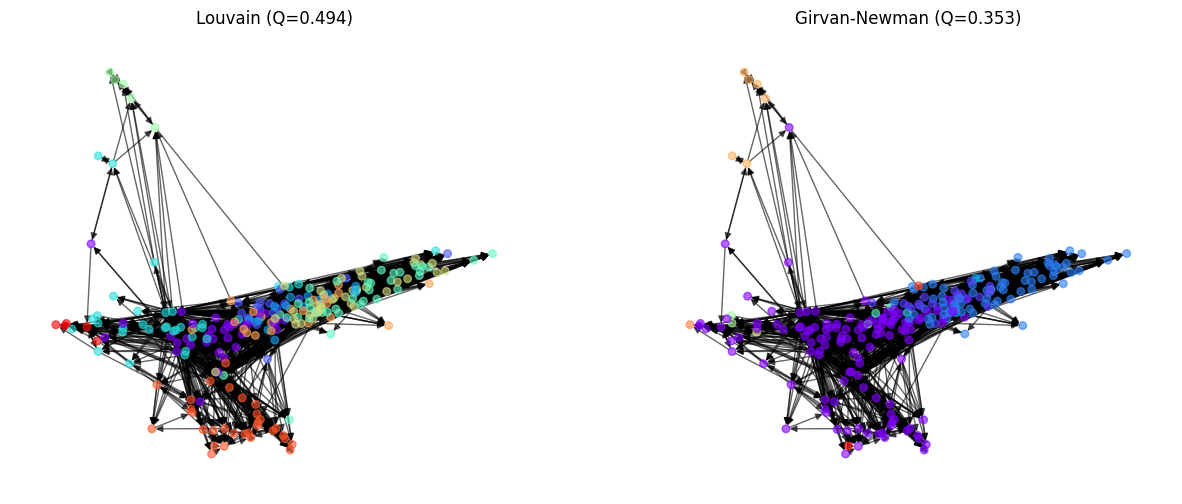

In [6]:
#Algoritmo de Girvan-Newman
comp_generator = community.girvan_newman(G)

best_modularity = -1
best_partition_gn = None
limit = 10

for i, communities in enumerate(comp_generator):
    current_mod = community.modularity(G, communities)
    
    if current_mod > best_modularity:
        best_modularity = current_mod
        best_partition_gn = communities

    if i > limit: 
        break

print(f"Modularidad máxima encontrada (Girvan-Newman): {best_modularity:.4f}")


In [ ]:

dict_partition_gn = {}
for i, comm in enumerate(best_partition_gn):
    for node in comm:
        dict_partition_gn[node] = i

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Visualización Louvain
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=30, node_color=list(partition_louvain.values()), 
        alpha=0.6, ax=ax[0], cmap=plt.cm.rainbow)
ax[0].set_title(f"Louvain (Q={modularity_louvain:.3f})")

# Visualización Girvan-Newman
nx.draw(G, pos, node_size=30, node_color=[dict_partition_gn[n] for n in G.nodes()], 
        alpha=0.6, ax=ax[1], cmap=plt.cm.rainbow)
ax[1].set_title(f"Girvan-Newman (Q={best_modularity:.3f})")

plt.show()